# Support Vector Classification (SVC): Titanic Survival Prediction

## Project objective
Build a reproducible binary classifier to predict whether a Titanic passenger survived, using a Support Vector Classifier (SVC).

This notebook covers:
- Data inspection and exploratory data analysis (EDA)
- Leakage-safe preprocessing with `ColumnTransformer` and `Pipeline`
- A baseline SVC and stratified cross-validation
- Hyperparameter tuning with `GridSearchCV`
- Final evaluation on a held-out test set
- Error analysis and model export

**Target:** `Survived` (`0` = did not survive, `1` = survived)

> The test set is reserved for final evaluation. Model selection and hyperparameter tuning use only the training set.

## 1. Imports and reproducibility

In [37]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

import joblib

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

warnings.filterwarnings("default")

## 2. Load the dataset

Expected repository layout:

```text
project-root/
├── data/
│   └── titanicDataset.csv
├── notebooks/
│   └── svc.ipynb
└── models/
```

The path logic below supports running this notebook from either the project root or the `notebooks/` directory.

In [38]:
candidate_paths = [
    Path("data/titanicDataset.csv"),
    Path("../data/titanicDataset.csv"),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    expected = "\n".join(f"- {path}" for path in candidate_paths)
    raise FileNotFoundError(
        "Could not find titanicDataset.csv. Check the dataset location. "
        f"Expected one of:\n{expected}"
    )

PROJECT_ROOT = DATA_PATH.resolve().parent.parent
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded from: {DATA_PATH.resolve()}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
display(df.head())

Dataset loaded from: C:\ML\SVM\data\titanicDataset.csv
Rows: 891 | Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Initial data inspection

In [39]:
display(df.info())
display(df.describe(include="all").T)

print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
})
display(missing_summary.sort_values("missing_percent", ascending=False))

print("\nTarget distribution:")
display(df["Survived"].value_counts().rename(index={0: "Did not survive", 1: "Survived"}))
display((df["Survived"].value_counts(normalize=True) * 100).round(2).rename(index={0: "Did not survive", 1: "Survived"}).rename("percent"))

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


Duplicate rows: 0

Missing values:


,missing_count,missing_percent
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00



Target distribution:


Survived
Did not survive    549
Survived           342
Name: count, dtype: int64

Survived
Did not survive    61.62
Survived           38.38
Name: percent, dtype: float64

## 4. Exploratory data analysis

These plots help explain the target distribution, missingness, and a few relationships with survival. They are descriptive; model settings are selected using cross-validation on the training data only.

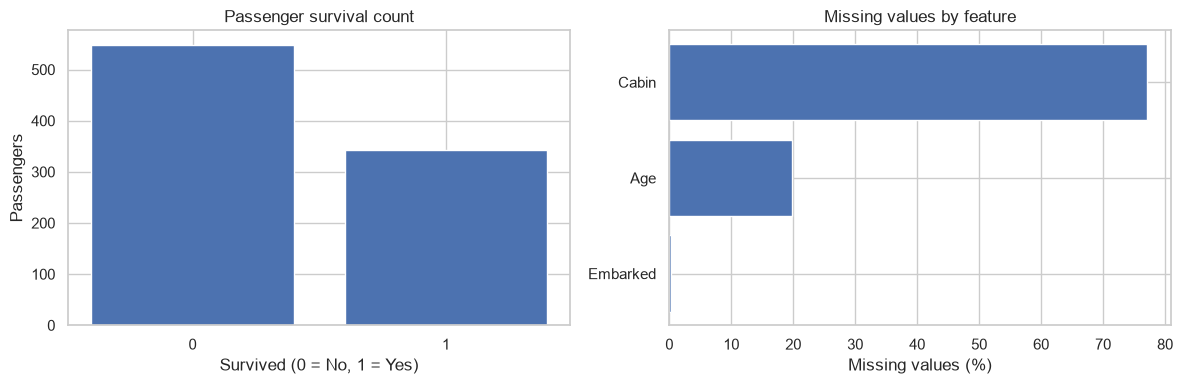

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df["Survived"].value_counts().reindex([0, 1], fill_value=0)
axes[0].bar(target_counts.index.astype(str), target_counts.values)
axes[0].set_title("Passenger survival count")
axes[0].set_xlabel("Survived (0 = No, 1 = Yes)")
axes[0].set_ylabel("Passengers")

missing_plot = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_percent")
axes[1].barh(missing_plot.index, missing_plot["missing_percent"])
axes[1].set_title("Missing values by feature")
axes[1].set_xlabel("Missing values (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

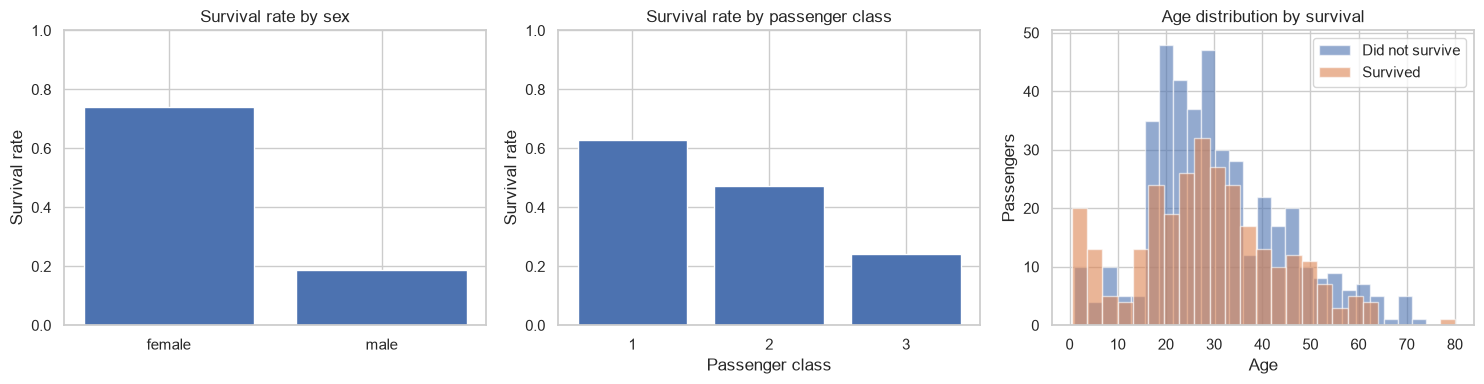

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

survival_by_sex = df.groupby("Sex", observed=False)["Survived"].mean().sort_index()
axes[0].bar(survival_by_sex.index.astype(str), survival_by_sex.values)
axes[0].set_title("Survival rate by sex")
axes[0].set_ylabel("Survival rate")
axes[0].set_ylim(0, 1)

survival_by_class = df.groupby("Pclass", observed=False)["Survived"].mean().sort_index()
axes[1].bar(survival_by_class.index.astype(str), survival_by_class.values)
axes[1].set_title("Survival rate by passenger class")
axes[1].set_xlabel("Passenger class")
axes[1].set_ylabel("Survival rate")
axes[1].set_ylim(0, 1)

for survived_value, label in [(0, "Did not survive"), (1, "Survived")]:
    ages = df.loc[df["Survived"] == survived_value, "Age"].dropna()
    axes[2].hist(ages, bins=25, alpha=0.6, label=label)
axes[2].set_title("Age distribution by survival")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Passengers")
axes[2].legend()

plt.tight_layout()
plt.show()

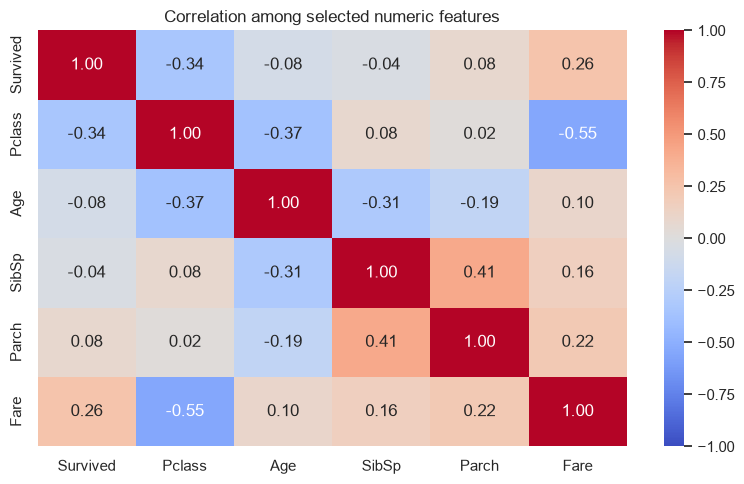

In [42]:
numeric_columns_for_corr = [
    column for column in ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
    if column in df.columns
]

plt.figure(figsize=(8, 5))
sns.heatmap(
    df[numeric_columns_for_corr].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
)
plt.title("Correlation among selected numeric features")
plt.tight_layout()
plt.show()

## 5. Define the target and features

The model uses `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, and `Embarked`.

`PassengerId` is an identifier. `Name`, `Ticket`, and `Cabin` are excluded from this baseline because they require additional feature engineering and/or have high cardinality or substantial missingness. They can be explored later as a separate experiment.

The preprocessing steps are placed inside a pipeline so imputers, encoders, and scalers are fitted only on the training folds during cross-validation.

In [43]:
required_columns = [
    "Survived", "Pclass", "Sex", "Age", "SibSp",
    "Parch", "Fare", "Embarked"
]
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

# This notebook assumes the target is labeled 0/1 and known for every row.
df = df.dropna(subset=["Survived"]).copy()
if not set(df["Survived"].unique()).issubset({0, 1}):
    raise ValueError("Expected Survived to contain only 0 and 1.")

FEATURES = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
TARGET = "Survived"

X = df[FEATURES].copy()
y = df[TARGET].astype(int).copy()

numerical_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]

print("Feature columns:", FEATURES)
print("Target counts:")
display(y.value_counts().sort_index().rename(index={0: "Did not survive", 1: "Survived"}))

Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Target counts:


Survived
Did not survive    549
Survived           342
Name: count, dtype: int64

## 6. Train-test split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
print("\nTraining target proportions:")
display(y_train.value_counts(normalize=True).sort_index().rename(index={0: "Did not survive", 1: "Survived"}))

Training rows: 712
Test rows: 179

Training target proportions:


Survived
Did not survive    0.616573
Survived           0.383427
Name: proportion, dtype: float64

## 7. Build the preprocessing and SVC pipeline

- Numerical features: median imputation followed by standardization.
- Categorical features: most-frequent imputation followed by one-hot encoding.
- Classifier: RBF-kernel SVC.

Scaling is important for SVMs because their decision boundary depends on distances and dot products.

In [45]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features),
])

svc_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf")),
])

svc_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 8. Establish a baseline with cross-validation

Before tuning, measure the default SVC using stratified 5-fold cross-validation on the **training data only**. F1-score is used as the selection metric for the positive class (`Survived = 1`).

This result is a baseline; it is not the final test-set score.

In [46]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

baseline_cv_scores = cross_val_score(
    svc_pipeline,
    X_train,
    y_train,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)

print("Default SVC CV F1 scores:", np.round(baseline_cv_scores, 4))
print(f"Mean CV F1: {baseline_cv_scores.mean():.4f}")
print(f"Standard deviation: {baseline_cv_scores.std():.4f}")

Default SVC CV F1 scores: [0.785  0.7327 0.7959 0.7115 0.7158]
Mean CV F1: 0.7482
Standard deviation: 0.0354


## 9. Hyperparameter tuning with GridSearchCV

The grid searches over:
- `C`: regularization strength (smaller values apply stronger regularization).
- `gamma`: influence range of individual training examples for the RBF kernel.
- `class_weight`: optionally compensates for class imbalance.

The cross-validation strategy is shuffled and stratified. The held-out test set is not used during model selection.

In [47]:
param_grid = {
    "classifier__C": [0.1, 1, 10, 100],
    "classifier__gamma": ["scale", 0.01, 0.1, 1],
    "classifier__class_weight": [None, "balanced"],
}

grid_search = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)
print(f"\nBest mean CV F1: {grid_search.best_score_:.4f}")

Best parameters:
{'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale'}

Best mean CV F1: 0.7667


In [48]:
cv_results = (
    pd.DataFrame(grid_search.cv_results_)
    .sort_values("rank_test_score")
    [[
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "params",
    ]]
    .head(10)
    .reset_index(drop=True)
)

display(cv_results)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
0,1,0.766701,0.037957,0.828823,"{'classifier__C': 10, 'classifier__class_weigh..."
1,2,0.761366,0.045065,0.812072,"{'classifier__C': 10, 'classifier__class_weigh..."
2,3,0.756705,0.044055,0.776089,"{'classifier__C': 100, 'classifier__class_weig..."
3,4,0.755891,0.038717,0.772514,"{'classifier__C': 100, 'classifier__class_weig..."
4,5,0.755833,0.031459,0.769231,"{'classifier__C': 1, 'classifier__class_weight..."
5,6,0.750998,0.030701,0.845279,"{'classifier__C': 1, 'classifier__class_weight..."
6,7,0.750971,0.024933,0.785828,"{'classifier__C': 1, 'classifier__class_weight..."
7,8,0.748935,0.020901,0.790848,"{'classifier__C': 10, 'classifier__class_weigh..."
8,9,0.748193,0.035413,0.780133,"{'classifier__C': 1, 'classifier__class_weight..."
9,10,0.747046,0.027588,0.779741,"{'classifier__C': 1, 'classifier__class_weight..."


## 10. Final evaluation on the held-out test set

This is the final evaluation of the selected model. Avoid repeatedly changing model settings in response to these results; doing so would turn the test set into part of the tuning process.

In [49]:
y_pred = best_model.predict(X_test)

# SVC has decision_function scores even with probability=False.
y_score = best_model.decision_function(X_test)

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Precision (survived)",
        "Recall (survived)",
        "F1-score (survived)",
        "ROC-AUC",
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        roc_auc_score(y_test, y_score),
    ],
})

# Format float values directly in pandas
final_metrics["Score"] = final_metrics["Score"].apply(lambda x: f"{x:.4f}")

display(final_metrics)

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Did not survive", "Survived"],
    zero_division=0,
))

,Metric,Score
0,Accuracy,0.7821
1,Balanced accuracy,0.7741
2,Precision (survived),0.7083
3,Recall (survived),0.7391
4,F1-score (survived),0.7234
5,ROC-AUC,0.8240


                 precision    recall  f1-score   support

Did not survive       0.83      0.81      0.82       110
       Survived       0.71      0.74      0.72        69

       accuracy                           0.78       179
      macro avg       0.77      0.77      0.77       179
   weighted avg       0.78      0.78      0.78       179



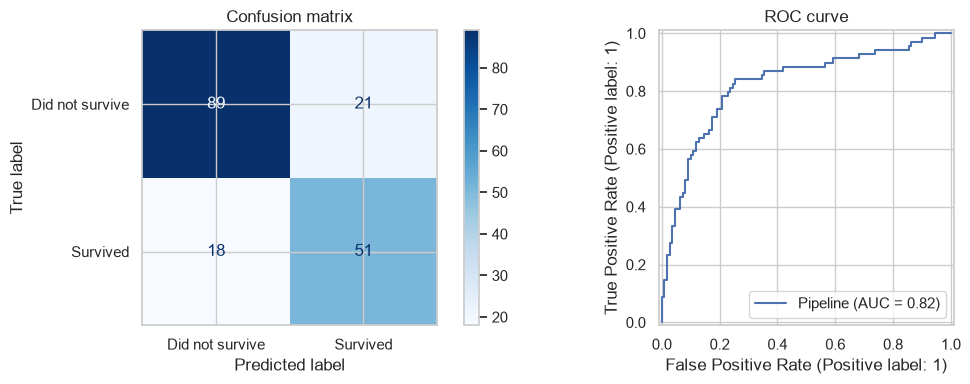

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Did not survive", "Survived"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    ax=axes[1],
)
axes[1].set_title("ROC curve")

plt.tight_layout()
plt.show()

## 11. Compare against a simple baseline

A model should be compared against a simple reference model. The `DummyClassifier` below always predicts the most frequent class observed in the training set. Both it and the selected SVC are evaluated on the same held-out test examples.

In [51]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)
dummy_pred = dummy_model.predict(X_test)

comparison = pd.DataFrame([
    {
        "Model": "DummyClassifier (most frequent)",
        "Accuracy": accuracy_score(y_test, dummy_pred),
        "Balanced accuracy": balanced_accuracy_score(y_test, dummy_pred),
        "Precision (survived)": precision_score(y_test, dummy_pred, zero_division=0),
        "Recall (survived)": recall_score(y_test, dummy_pred, zero_division=0),
        "F1 (survived)": f1_score(y_test, dummy_pred, zero_division=0),
    },
    {
        "Model": "Tuned SVC",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision (survived)": precision_score(y_test, y_pred, zero_division=0),
        "Recall (survived)": recall_score(y_test, y_pred, zero_division=0),
        "F1 (survived)": f1_score(y_test, y_pred, zero_division=0),
    },
])

# Round all float columns to 4 decimal places
display(comparison.set_index("Model").round(4))

,Accuracy,Balanced accuracy,Precision (survived),Recall (survived),F1 (survived)
Model,,,,,
DummyClassifier (most frequent),0.6145,0.5000,0.0000,0.0000,0.0000
Tuned SVC,0.7821,0.7741,0.7083,0.7391,0.7234


## 12. Inspect misclassified examples

This section shows test-set rows the selected model classified incorrectly. Use it to generate hypotheses for further experiments, not to claim that individual errors have a single known cause.

In [52]:
misclassified_mask = (y_test.to_numpy() != y_pred)
misclassified_indices = y_test.index[misclassified_mask]

error_columns = [
    "Survived", "Pclass", "Sex", "Age", "SibSp",
    "Parch", "Fare", "Embarked",
]
misclassified = df.loc[misclassified_indices, error_columns].copy()
misclassified["PredictedSurvived"] = y_pred[misclassified_mask]

print(f"Misclassified test examples: {len(misclassified)} of {len(y_test)}")
display(misclassified.head(20))

Misclassified test examples: 39 of 179


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,PredictedSurvived
553,1,3,male,22.0,0,0,7.2250,C,0
559,1,3,female,36.0,1,0,17.4000,S,0
698,0,1,male,49.0,1,1,110.8833,C,1
817,0,2,male,31.0,1,1,37.0042,C,1
27,0,1,male,19.0,3,2,263.0000,S,1
279,1,3,female,35.0,1,1,20.2500,S,0
455,1,3,male,29.0,0,0,7.8958,C,0
297,0,1,female,2.0,1,2,151.5500,S,1
564,0,3,female,NaN,0,0,8.0500,S,1
502,0,3,female,NaN,0,0,7.6292,Q,1


## 13. Save the complete fitted pipeline

Saving the complete pipeline preserves the fitted imputer, scaler, encoder, and classifier. At prediction time, pass a DataFrame containing the same raw feature columns used during training.

In [53]:
model_dir = PROJECT_ROOT / "models"
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "svc_titanic_model.joblib"
joblib.dump(best_model, model_path)

print(f"Saved model to: {model_path.resolve()}")

Saved model to: C:\ML\SVM\models\svc_titanic_model.joblib


In [54]:

loaded_model = joblib.load(model_path)

sample_passengers = X_test.head(5)
sample_predictions = loaded_model.predict(sample_passengers)

display(sample_passengers.assign(PredictedSurvived=sample_predictions))

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,PredictedSurvived
565,3,male,24.0,2,0,24.1500,S,0
160,3,male,44.0,0,1,16.1000,S,0
553,3,male,22.0,0,0,7.2250,C,0
860,3,male,41.0,2,0,14.1083,S,0
241,3,female,NaN,1,0,15.5000,Q,1


## 14. Conclusions and limitations

1. **Limitations:** this is a small, historical dataset; results do not establish generalization to other populations or modern passenger data.
